# 🔍 Bias Detection
Run AFTER `02_training_testing.ipynb`

---
### Cells
1. Imports & Config
2. Dataset-Level Bias
3. Image Property Bias
4. Model Prediction Bias
5. Bias Summary & Plots

## Cell 1 — Imports & Config

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
warnings.filterwarnings('ignore')
from pathlib import Path
from collections import Counter
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

DATASET_PATH = r'D:\Files\AI X-Ray Detection\Dataset_Cleaned'
ORIG_PATH    = r'D:\Files\AI X-Ray Detection\Dataset'
MODELS_PATH  = r'D:\Files\AI X-Ray Detection\Models'
RESULTS_PATH = r'D:\Files\AI X-Ray Detection\Reports'
CLASSES      = ['normal', 'pneumonia', 'tuberculosis']
SPLITS       = ['train', 'val', 'test']
VALID_EXTS   = {'.jpg','.jpeg','.png','.bmp'}
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 16
RECALL_THRESHOLD     = 0.75
CONFIDENCE_THRESHOLD = 0.60

if not os.path.exists(DATASET_PATH):
    DATASET_PATH = ORIG_PATH

print('✅ Config ready')
print(f'   Dataset: {DATASET_PATH}')

✅ Config ready
   Dataset: D:\Files\AI X-Ray Detection\Dataset_Cleaned


## Cell 2 — Dataset-Level Bias


  Split      Class                 Count      Pct Status
  --------------------------------------------------------
  train      normal                 9000    33.3%  ✅ OK
  train      pneumonia              9000    33.3%  ✅ OK
  train      tuberculosis           9000    33.3%  ✅ OK
  val        normal                  600    33.3%  ✅ OK
  val        pneumonia               600    33.3%  ✅ OK
  val        tuberculosis            600    33.3%  ✅ OK
  test       normal                  476    32.8%  ✅ OK
  test       pneumonia               432    29.8%  ✅ OK
  test       tuberculosis            543    37.4%  ✅ OK

  Imbalance Ratios:
    [train] 1.00x  ✅ Balanced
    [val] 1.00x  ✅ Balanced
    [test] 1.26x  ✅ Balanced


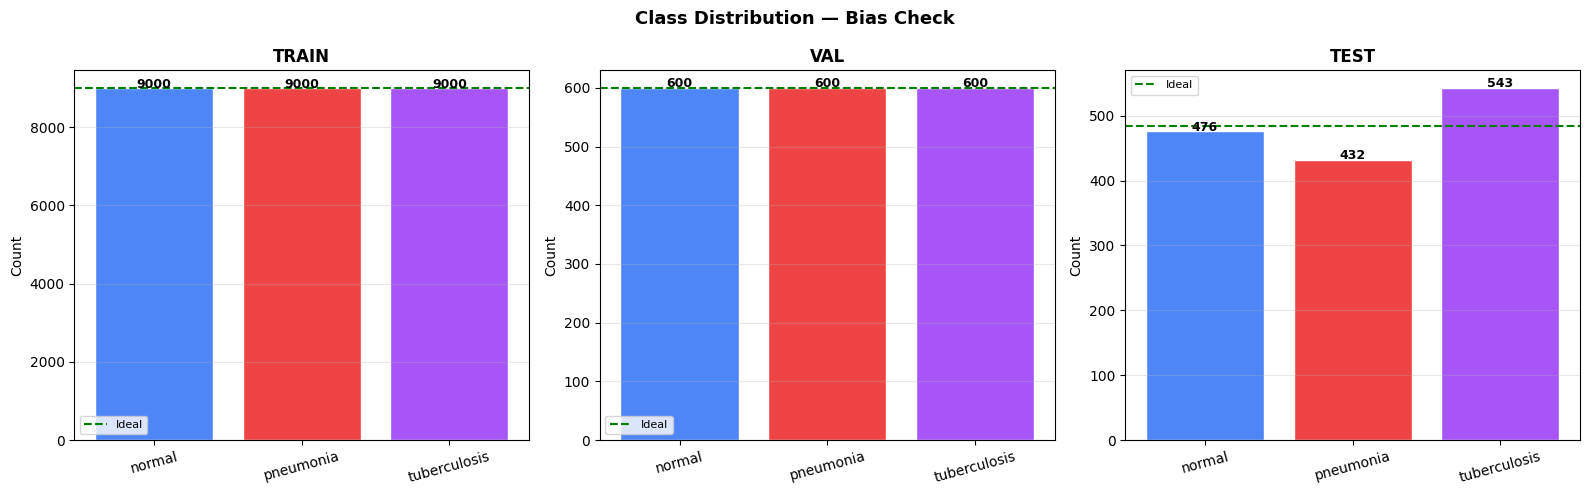

✅ Dataset bias analysis complete


In [2]:
def count_dist(base_path):
    dist = {}
    for split in SPLITS:
        dist[split] = {}
        for cls in CLASSES:
            p = os.path.join(base_path, split, cls)
            dist[split][cls] = len([f for f in os.listdir(p)
                if Path(f).suffix.lower() in VALID_EXTS]) if os.path.isdir(p) else 0
    return dist

dist = count_dist(DATASET_PATH)

print(f'\n  {"Split":<10} {"Class":<18} {"Count":>8} {"Pct":>8} {"Status"}')
print(f'  {"-"*56}')
rows = []
for split, classes in dist.items():
    total = sum(classes.values())
    for cls, count in classes.items():
        pct    = count/total*100 if total > 0 else 0
        ideal  = 100/len(CLASSES)
        dev    = abs(pct - ideal)
        status = '✅ OK' if dev < 10 else ('⚠️  WARN' if dev < 20 else '❌ BIASED')
        print(f'  {split:<10} {cls:<18} {count:>8} {pct:>7.1f}%  {status}')
        rows.append({'split':split,'class':cls,'count':count,'pct':round(pct,2),'status':status})

pd.DataFrame(rows).to_csv(os.path.join(RESULTS_PATH, 'bias_dataset.csv'), index=False)

print(f'\n  Imbalance Ratios:')
for split, classes in dist.items():
    counts = [v for v in classes.values() if v > 0]
    if counts:
        ratio = max(counts)/min(counts)
        flag  = '✅ Balanced' if ratio<1.3 else ('⚠️  Mild' if ratio<2.0 else '❌ Severe')
        print(f'    [{split}] {ratio:.2f}x  {flag}')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Class Distribution — Bias Check', fontsize=13, fontweight='bold')
colors = ['#4f86f7','#ef4444','#a855f7']
for ax, (split, classes) in zip(axes, dist.items()):
    bars = ax.bar(list(classes.keys()), list(classes.values()),
                  color=colors, edgecolor='white')
    total = sum(classes.values())
    if total > 0:
        ideal = total / len(CLASSES)
        ax.axhline(y=ideal, color='green', linestyle='--', label='Ideal')
    for bar, v in zip(bars, classes.values()):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+1,
                str(v), ha='center', fontweight='bold', fontsize=9)
    ax.set_title(split.upper(), fontweight='bold')
    ax.set_ylabel('Count'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'bias_distribution.png'), dpi=150)
plt.show()
print('✅ Dataset bias analysis complete')

## Cell 3 — Image Property Bias

Analyzing image properties (brightness, contrast, size)...

  Class              Brightness     Contrast    Avg Width
  --------------------------------------------------------
  normal                  127.7         60.5          802
  pneumonia               119.4         58.5         1308
  tuberculosis            130.2         56.3          336


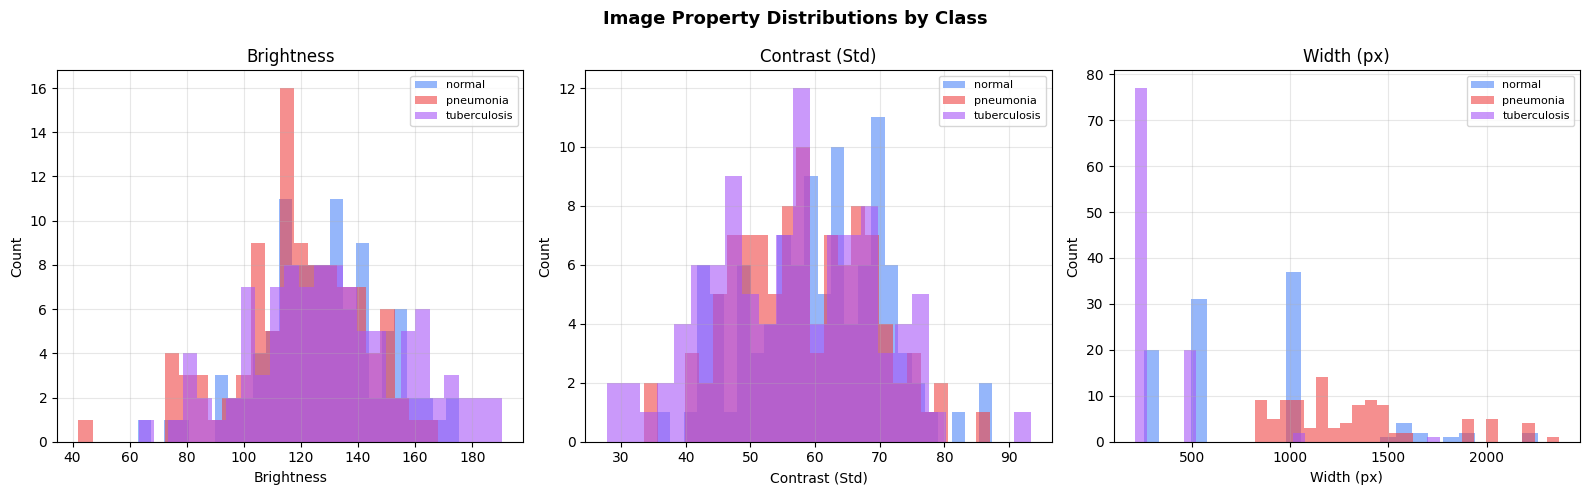

✅ Image property bias analysis complete


In [3]:
print('Analyzing image properties (brightness, contrast, size)...')
props = {cls: {'brightness':[],'contrast':[],'width':[],'height':[]} for cls in CLASSES}
MAX_PER_CLASS = 100

for cls in CLASSES:
    cls_path = os.path.join(DATASET_PATH, 'train', cls)
    if not os.path.isdir(cls_path): continue
    files = [f for f in os.listdir(cls_path)
             if Path(f).suffix.lower() in VALID_EXTS][:MAX_PER_CLASS]
    for fname in files:
        try:
            img = np.array(Image.open(os.path.join(cls_path,fname)).convert('L'))
            props[cls]['brightness'].append(float(np.mean(img)))
            props[cls]['contrast'].append(float(np.std(img)))
            h, w = img.shape
            props[cls]['width'].append(w)
            props[cls]['height'].append(h)
        except: pass

print(f'\n  {"Class":<16} {"Brightness":>12} {"Contrast":>12} {"Avg Width":>12}')
print(f'  {"-"*56}')
prop_rows = []
for cls in CLASSES:
    p = props[cls]
    if p['brightness']:
        b = np.mean(p['brightness'])
        c = np.mean(p['contrast'])
        w = np.mean(p['width'])
        print(f'  {cls:<16} {b:>12.1f} {c:>12.1f} {w:>12.0f}')
        prop_rows.append({'class':cls,'mean_brightness':round(b,2),'mean_contrast':round(c,2)})

pd.DataFrame(prop_rows).to_csv(os.path.join(RESULTS_PATH,'bias_image_properties.csv'),index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Image Property Distributions by Class', fontsize=13, fontweight='bold')
colors = ['#4f86f7','#ef4444','#a855f7']
for ax, prop, title in zip(axes,
        ['brightness','contrast','width'],
        ['Brightness','Contrast (Std)','Width (px)']):
    for cls, color in zip(CLASSES, colors):
        if props[cls][prop]:
            ax.hist(props[cls][prop], bins=25, alpha=0.6, color=color, label=cls)
    ax.set_title(title); ax.set_xlabel(title); ax.set_ylabel('Count')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH,'bias_image_properties.png'), dpi=150)
plt.show()
print('✅ Image property bias analysis complete')

## Cell 4 — Model Prediction Bias

Loading: EfficientNetB4_finetuned...
Found 1451 images belonging to 3 classes.
91/91 ━━━━━━━━━━━━━━━━━━━━ 51s 526ms/step

  Prediction vs True Distribution:
  Class                  True    Predicted    Ratio Status
  ------------------------------------------------------
  normal                  476          496     1.04  ✅
  pneumonia               432          461     1.07  ✅
  tuberculosis            543          494     0.91  ✅

  Per-class Recall:
  normal             recall=0.853  conf=0.744  ✅
  pneumonia          recall=0.972  conf=0.820  ✅
  tuberculosis       recall=0.816  conf=0.751  ✅


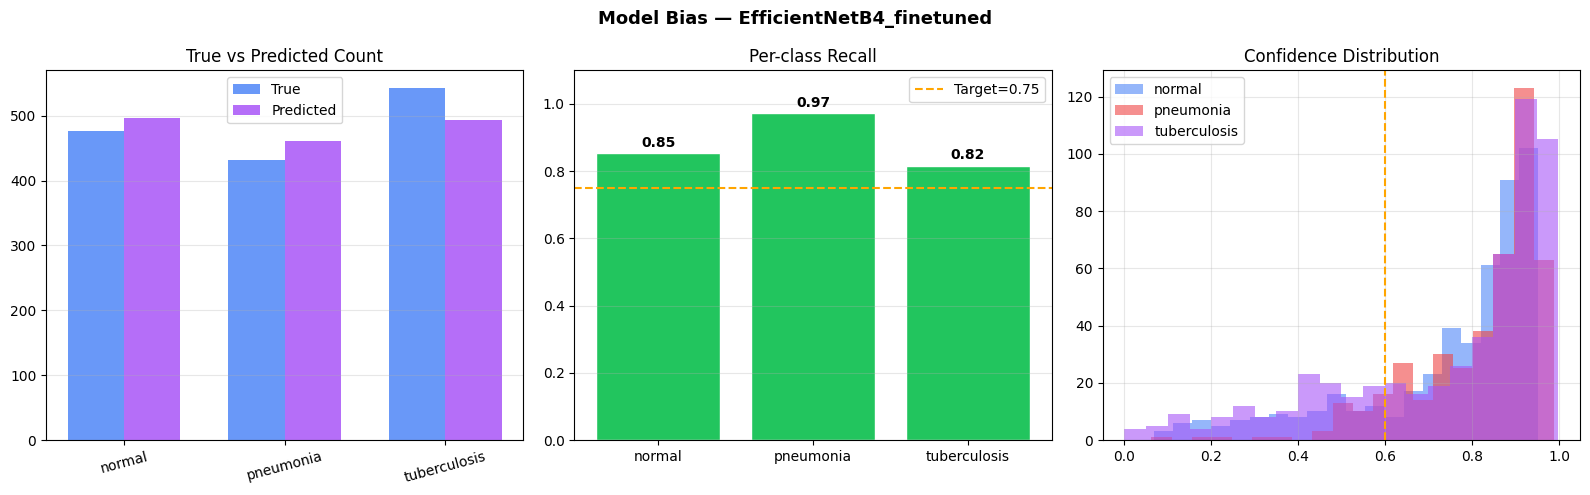

✅ Model bias analysis complete


In [4]:
best_info_path = os.path.join(RESULTS_PATH, 'best_model_info.json')
if not os.path.exists(best_info_path):
    print('⚠️  No trained model found — run 02_training_testing.ipynb first')
else:
    with open(best_info_path) as f:
        best_info = json.load(f)
    model_path  = best_info['model_path']
    CLASS_NAMES = best_info['class_names']
    print(f'Loading: {best_info["best_model"]}...')
    model = tf.keras.models.load_model(model_path, compile=False)

    test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
        os.path.join(DATASET_PATH,'test'), target_size=IMG_SIZE,
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

    test_gen.reset()
    y_pred         = model.predict(test_gen, verbose=1)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true         = test_gen.classes
    detected_names = list(test_gen.class_indices.keys())
    n_cls          = len(detected_names)

    pred_counts = Counter(y_pred_classes)
    true_counts = Counter(y_true)

    print(f'\n  Prediction vs True Distribution:')
    print(f'  {"Class":<18} {"True":>8} {"Predicted":>12} {"Ratio":>8} Status')
    print(f'  {"-"*54}')
    pred_rows = []
    for idx, cls in enumerate(detected_names):
        t = true_counts.get(idx, 0)
        p = pred_counts.get(idx, 0)
        r = p/t if t > 0 else 0
        flag = '✅' if 0.8<=r<=1.2 else '⚠️  BIAS'
        print(f'  {cls:<18} {t:>8} {p:>12} {r:>8.2f}  {flag}')
        pred_rows.append({'class':cls,'true':t,'predicted':p,'ratio':round(r,3)})
    pd.DataFrame(pred_rows).to_csv(os.path.join(RESULTS_PATH,'bias_prediction.csv'),index=False)

    print(f'\n  Per-class Recall:')
    conf_rows = []
    for idx, cls in enumerate(detected_names):
        mask = y_true == idx
        if mask.sum() == 0: continue
        rec  = float(np.sum(y_pred_classes[mask]==idx)/mask.sum())
        conf = float(np.mean(y_pred[mask, idx]))
        flag = '✅' if rec>=RECALL_THRESHOLD else '❌ LOW — model biased against this class'
        print(f'  {cls:<18} recall={rec:.3f}  conf={conf:.3f}  {flag}')
        conf_rows.append({'class':cls,'recall':round(rec,4),'mean_conf':round(conf,4)})
    pd.DataFrame(conf_rows).to_csv(os.path.join(RESULTS_PATH,'bias_confidence.csv'),index=False)

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Model Bias — {best_info["best_model"]}', fontsize=13, fontweight='bold')
    colors = ['#4f86f7','#ef4444','#a855f7']

    x = np.arange(len(detected_names)); w = 0.35
    axes[0].bar(x-w/2,[true_counts.get(i,0) for i in range(n_cls)],w,label='True',color='#4f86f7',alpha=0.85)
    axes[0].bar(x+w/2,[pred_counts.get(i,0) for i in range(n_cls)],w,label='Predicted',color='#a855f7',alpha=0.85)
    axes[0].set_xticks(x); axes[0].set_xticklabels(detected_names,rotation=15)
    axes[0].set_title('True vs Predicted Count'); axes[0].legend(); axes[0].grid(axis='y',alpha=0.3)

    recalls = [r['recall'] for r in conf_rows]
    bar_colors = ['#22c55e' if r>=RECALL_THRESHOLD else '#ef4444' for r in recalls]
    axes[1].bar(detected_names, recalls, color=bar_colors, edgecolor='white')
    axes[1].axhline(y=RECALL_THRESHOLD,color='orange',linestyle='--',label=f'Target={RECALL_THRESHOLD}')
    axes[1].set_ylim(0,1.1); axes[1].set_title('Per-class Recall')
    axes[1].legend(); axes[1].grid(axis='y',alpha=0.3)
    for i,(nm,rec) in enumerate(zip(detected_names,recalls)):
        axes[1].text(i,rec+0.02,f'{rec:.2f}',ha='center',fontweight='bold')

    for idx,(cls,color) in enumerate(zip(detected_names,colors)):
        mask = y_true==idx
        if mask.sum()>0:
            axes[2].hist(y_pred[mask,idx],bins=20,alpha=0.6,color=color,label=cls)
    axes[2].axvline(x=CONFIDENCE_THRESHOLD,color='orange',linestyle='--')
    axes[2].set_title('Confidence Distribution'); axes[2].legend(); axes[2].grid(True,alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_PATH,'bias_model_analysis.png'),dpi=150)
    plt.show()
    print('✅ Model bias analysis complete')

## Cell 5 — Bias Summary

In [5]:
print('BIAS DETECTION SUMMARY')
print('='*55)
summary = []
for split, classes in dist.items():
    counts = list(classes.values())
    ratio  = max(counts)/(min(counts)+1e-9)
    summary.append({'check':f'Dataset imbalance ({split})','value':f'{ratio:.2f}x',
                    'status':'PASS' if ratio<1.3 else ('WARN' if ratio<2.0 else 'FAIL')})

for row in summary:
    icon = '✅' if row['status']=='PASS' else ('⚠️ ' if row['status']=='WARN' else '❌')
    print(f'  {row["check"]:<40} {row["value"]:>10}  {icon}')

pd.DataFrame(summary).to_csv(os.path.join(RESULTS_PATH,'bias_summary.csv'),index=False)
print(f'\n✅ All bias reports saved → {RESULTS_PATH}')

BIAS DETECTION SUMMARY
  Dataset imbalance (train)                     1.00x  ✅
  Dataset imbalance (val)                       1.00x  ✅
  Dataset imbalance (test)                      1.26x  ✅

✅ All bias reports saved → D:\Files\AI X-Ray Detection\Reports
